In [ ]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation, SumAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm
import sys
import os
# Add the project root to the Python path
project_root = '/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique'
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import TUDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
from bcosgnn.evaluation import get_attribution_scores

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


## Bcos Model Definition

In [4]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out

class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

import torch
from torch_geometric.nn import MessagePassing

class BcosGINEConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        edge_dim: int,
        b: float = 2.0,
        max_out: int = 1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs
    ):
        # We use 'add' aggregation to stay true to the GIN formula
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        
        # The MLP part of GIN, but using B-cos layers
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index, edge_attr):
        # edge_attr is expected to be pre-projected to match x dimension
        # in your main model loop.
        
        # 1. Propagate messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        
        # 2. Combine step: (1 + eps) * center_node + aggregated_messages
        out = (1 + self.eps) * x + out
        
        # 3. Apply the B-cos MLP transformation
        return self.transform(out)

    def message(self, x_j, edge_attr):
        # Standard GINE uses ReLU(x_j + edge_attr).
        # In pure B-cos, we can use the addition, then the B-cos transform 
        # in the 'forward' call handles the non-linear alignment.
        return torch.nn.functional.relu(x_j + edge_attr)

In [5]:
class PureBcosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5, # Added this to the signature
    ):
        super().__init__()
        
        # 1. Initial Embeddings
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        
        # 2. Convolutional Layers
        self.convs = nn.ModuleList([
            BcosGINEConv(
                channels=[hidden_dim, hidden_dim], 
                edge_dim=hidden_dim, 
                b=b, 
                max_out=max_out
            ) for _ in range(num_layers)
        ])
        
        # 3. Readout (Per-node MLP)
        self.readout_mlp = BcosSequential(
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
            BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)
        )
        
        # 4. Dropout and Aggregation
        self.dropout_layer = nn.Dropout(dropout) # Added dropout layer
        self.agg = SumAggregation()

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.lin_node(x)
        e = self.lin_edge(edge_attr)
        
        for conv in self.convs:
            x = conv(x, edge_index, e)
        
        # Readout Then Agg logic
        # Step A: Transform node features to class logits
        node_logits = self.readout_mlp(x)
        
        # Step B: Apply dropout to the node-level contributions
        node_logits = self.dropout_layer(node_logits)
        
        # Step C: Aggregate into graph-level logits
        graph_logits = self.agg(node_logits, batch)
        
        return graph_logits

In [18]:

# 4-layer BCos-GINE for `zinc_dichloro` (continuous x and edge_attr)
class BCosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        *,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        self.convs = nn.ModuleList([
            GINEConv(BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out), train_eps=False)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)])
        self.agg = SumAggregation()
        self.dropout = nn.Dropout(dropout)
        self.head = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
        g = self.agg(x, batch)
        g = self.dropout(g)
        return self.head(g)  # [num_graphs, num_classes]

In [6]:
import time
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def _infer_num_classes(ds) -> int:
    ys = torch.tensor([ds[i].y.item() for i in range(len(ds))], dtype=torch.long)
    return int(torch.unique(ys).numel())


def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))
    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds

In [7]:
def train_one_run_bcos(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    set_seed(seed)
    device = device or get_device()

    sample = dataset[0]
    node_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = _infer_num_classes(dataset)

    model = PureBcosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_layers=4,
        num_classes=num_classes,
        b=b,
        max_out=max_out,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }



In [14]:
def run_multiseed_5fold_bcos(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        _trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run_bcos(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
                b=b,
                max_out=max_out,
                dropout=dropout,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY (BCos-GINE)")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }


In [8]:
BCOS_RESULTS = run_multiseed_5fold_bcos(
    dataset,
    seeds=(0, 1, 2),
    k_folds=5,
    test_size=0.2,
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
)

Device: cuda
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001

Seed 0 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=68 | 58.4s
Seed 0 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=69 | 59.6s
Seed 0 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=61 | 50.6s
Seed 0 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=85 | 73.3s
Seed 0 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=70 | 59.7s
Seed 0 summary: mean_test_acc=1.0000 ± 0.0000
Seed 1 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=71 | 58.5s
Seed 1 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=75 | 63.4s
Seed 1 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=79 | 60.4s
Seed 1 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=86 | 70.2s
Seed 1 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=75 | 61.5s
Seed 1 summary: mean_te

### Training Report Bcos

In [9]:
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(BCOS_RESULTS)

================ Per-fold runs (seed, fold) ================


,seed,fold,test_acc,test_loss,best_val_acc,best_val_loss,epochs_ran
0,0,1,1.0,0.000065,1.0,0.000056,68
1,0,2,1.0,0.000085,1.0,0.000084,69
2,0,3,1.0,0.000118,1.0,0.000116,61
3,0,4,1.0,0.000021,1.0,0.000021,85
4,0,5,1.0,0.000077,1.0,0.000078,70
5,1,1,1.0,0.000077,1.0,0.000084,71
6,1,2,1.0,0.000049,1.0,0.000053,75
7,1,3,1.0,0.000035,1.0,0.000041,79
8,1,4,1.0,0.000014,1.0,0.000013,86
9,1,5,1.0,0.000027,1.0,0.000028,75



================ Per-seed summary ================


,seed,n_folds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,0,5,1.0,0.0,0.000073,1.0,70.6
1,1,5,1.0,0.0,0.000040,1.0,77.2
2,2,5,1.0,0.0,0.000055,1.0,75.8



================ Overall (all folds × all seeds) ================


,n_runs,n_seeds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,15,3,1.0,0.0,0.000056,1.0,74.533333


### Explainations

In [8]:
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

from bcosgnn.explain_edge_attr import explain as explain_edge_attr


In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 0
TEST_SIZE = 0.1

HIDDEN_DIM = 128
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

# BCos params (match your training cell)
BCOS_B = 2.5
BCOS_MAX_OUT = 1
DROPOUT = 0.5


In [10]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_labels(ds):
    ys = []
    for d in ds:
        y = d.y
        if torch.is_tensor(y):
            y = int(y.view(-1)[0].item())
        ys.append(y)
    return np.array(ys, dtype=np.int64)


def stratified_trainval_test_split(ds, test_size=0.2, seed=0):
    y = get_labels(ds)
    idx = np.arange(len(ds))

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(sss.split(idx, y))

    return trainval_idx, test_idx

In [11]:
def train_final_model_with_holdout(trainval_ds, num_classes: int, seed: int):
    # small val split for early stopping (10% of trainval)
    y = get_labels(trainval_ds)
    idx = np.arange(len(trainval_ds))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, va_idx = next(sss.split(idx, y))

    train_ds = [trainval_ds[i] for i in tr_idx]
    val_ds = [trainval_ds[i] for i in va_idx]

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    node_dim = int(trainval_ds[0].x.shape[-1])
    edge_dim = int(trainval_ds[0].edge_attr.shape[-1]) if getattr(trainval_ds[0], "edge_attr", None) is not None else 0

    model = PureBcosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        b=BCOS_B,
        max_out=BCOS_MAX_OUT,
        dropout=DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = F.cross_entropy(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_true, val_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(logits, batch.y.view(-1))
                val_losses.append(loss.item())
                val_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
                val_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        val_acc = accuracy_score(val_true, val_pred) if len(val_true) else float("nan")

        sched.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d} | train_loss={np.mean(train_losses):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={lr_now:.2e}")

        if bad >= EARLY_STOP_PATIENCE:
            print(f"Early stop at epoch {epoch} (best epoch {best_epoch}, best val_loss {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_epoch": best_epoch, "best_val_loss": best_val_loss}

In [12]:

def eval_accuracy(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())
    return accuracy_score(y_true, y_pred)

In [12]:
def node_scores_from_contrib(x_contrib: torch.Tensor) -> np.ndarray:
    # x_contrib: [num_nodes, num_features] -> scalar per node
    scores = x_contrib.abs().sum(dim=-1)
    return scores.detach().cpu().numpy()


def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    if k <= 0:
        return float("nan")
    top_idx = np.argsort(scores)[-k:]
    pred = np.zeros_like(gt_mask, dtype=bool)
    pred[top_idx] = True
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else float("nan")

In [14]:
seed_everything(SEED)

num_classes = int(get_labels(dataset).max() + 1)

print(f"Number of classes: {num_classes}")

Number of classes: 9


In [15]:
trainval_idx, test_idx = stratified_trainval_test_split(dataset, test_size=TEST_SIZE, seed=SEED)
trainval_ds = [dataset[i] for i in trainval_idx]
print(len(trainval_ds))  # number of trainval graphs
test_ds = [dataset[i] for i in test_idx]
print(len(test_ds))  # number of test graphs to explain
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

final_model, training_info = train_final_model_with_holdout(trainval_ds, num_classes=num_classes, seed=SEED)
print(f"Final model trained. Best val loss: {training_info['best_val_loss']:.4f} at epoch {training_info['best_epoch']}")
print(f"Evaluating final model on test set of {len(test_ds)} graphs...")
test_acc = eval_accuracy(final_model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

8100
900
Epoch 001 | train_loss=2.1980 | val_loss=2.1972 | val_acc=0.1111 | lr=1.00e-03
Epoch 001 | train_loss=2.1980 | val_loss=2.1972 | val_acc=0.1111 | lr=1.00e-03
Epoch 010 | train_loss=0.0067 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 010 | train_loss=0.0067 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0101 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0101 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 030 | train_loss=0.0028 | val_loss=0.0002 | val_acc=1.0000 | lr=1.00e-03
Epoch 030 | train_loss=0.0028 | val_loss=0.0002 | val_acc=1.0000 | lr=1.00e-03
Early stop at epoch 34 (best epoch 9, best val_loss 0.0000)
Final model trained. Best val loss: 0.0000 at epoch 9
Evaluating final model on test set of 900 graphs...
Early stop at epoch 34 (best epoch 9, best val_loss 0.0000)
Final model trained. Best val loss: 0.0000 at epoch 9
Evaluating final model on test set of 900 graphs...
Final test accuracy: 1.0000

### Explanations on test set

In [16]:
final_model.eval()

N_EXPLAIN = len(test_ds)

TOPK_MODE = "gt"  # "gt" = k = (#gt nodes), or set integer like 10

rng = np.random.default_rng(SEED)

pick = rng.choice(len(test_ds), size=min(N_EXPLAIN, len(test_ds)), replace=False)

aurocs = []

jaccs = []

for i in pick:
    d = test_ds[int(i)]
    if not hasattr(d, "explanation_mask") or d.explanation_mask is None:
        continue

    # Single-graph "batch"
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())

    contrib = explain_edge_attr(
        final_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=pred_class,
    )

    scores = node_scores_from_contrib(contrib["x"])
    gt = d.explanation_mask.detach().cpu().numpy().astype(int)

    # AUROC (skip degenerate gt)
    if gt.min() != gt.max():
        aurocs.append(roc_auc_score(gt, scores))

    # Jaccard@k
    if TOPK_MODE == "gt":
        k = int(gt.sum())
    else:
        k = int(TOPK_MODE)
    if k > 0:
        jaccs.append(jaccard_at_k(scores, gt, k))

if aurocs:
    print(f"Node AUROC: mean={np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1) if len(aurocs)>1 else 0.0:.4f} (n={len(aurocs)})")
else:
    print("Node AUROC: n=0 (no non-degenerate ground-truth masks found)")

if jaccs:
    print(f"Jaccard@k: mean={np.mean(jaccs):.4f} ± {np.std(jaccs, ddof=1) if len(jaccs)>1 else 0.0:.4f} (n={len(jaccs)})")
else:
    print("Jaccard@k: n=0 (no valid k/gt masks)")


Node AUROC: mean=0.9950 ± 0.0095 (n=900)
Jaccard@k: mean=0.9173 ± 0.1196 (n=900)


Generating RDKit visualizations...


[03:03:24] Explicit valence for atom # 6 N, 4, is greater than permitted
[03:03:24] Explicit valence for atom # 6 N, 4, is greater than permitted


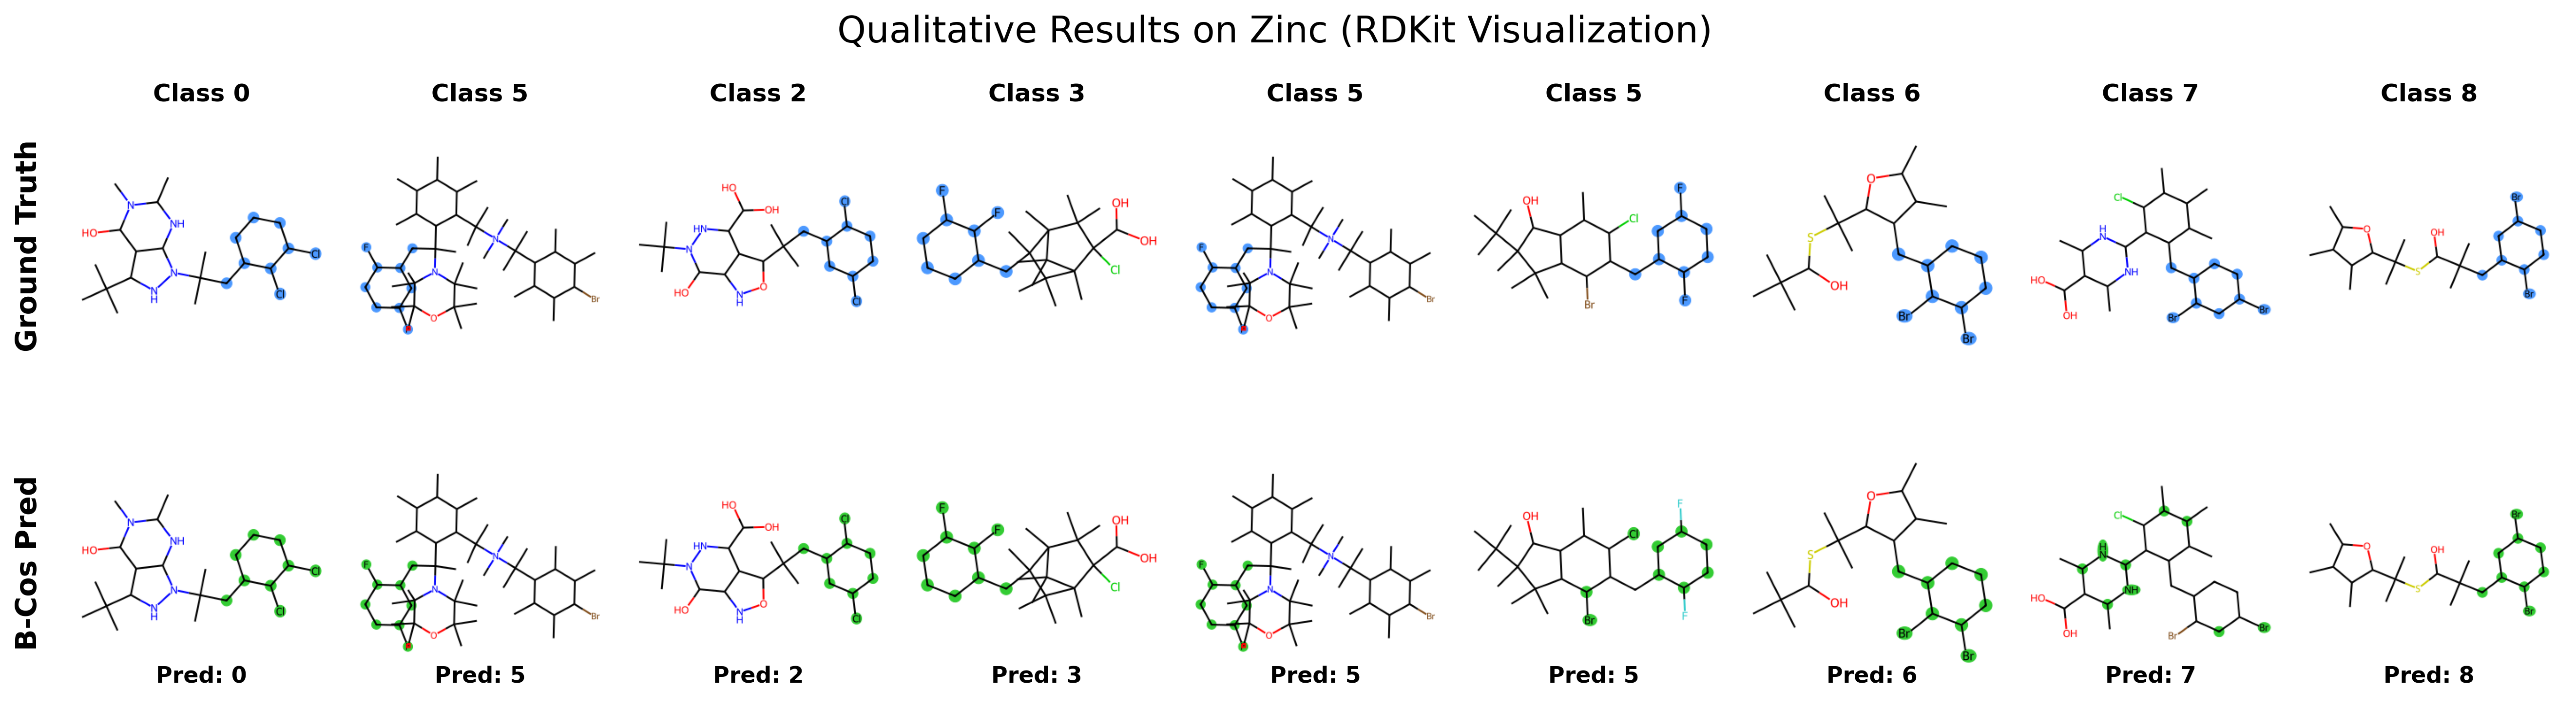

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# -------------------------------------------------------------------------
# 1. RDKit Conversion Utilities
# -------------------------------------------------------------------------
# ZINC atom map (Must match your dataset's feature encoding)
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15} # Atomic nums

def pyg_to_rdkit(data):
    """
    Converts a PyG graph to an RDKit molecule.
    Crucial step: We must infer bond types (Single, Double, Aromatic) 
    since standard GNN datasets often only store connectivity.
    """
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # 1. Add Atoms
    for i in range(data.num_nodes):
        # Decode atom type
        if data.x.dim() > 1:
            atom_idx = data.x[i].argmax().item()
        else:
            atom_idx = int(data.x[i].item())
        
        atomic_num = ATOM_MAP.get(atom_idx, 6) # Default to Carbon if unknown
        atom = Chem.Atom(atomic_num)
        idx = mol.AddAtom(atom)
        node_to_idx[i] = idx

    # 2. Add Bonds (Initially all Single)
    edge_index = data.edge_index.cpu().numpy()
    # Use set to avoid adding double bonds for undirected edges (u,v) and (v,u)
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        u, v = edge_index[0, k], edge_index[1, k]
        if u < v: # store only one direction
            mol.AddBond(int(node_to_idx[u]), int(node_to_idx[v]), Chem.BondType.SINGLE)
    
    # 3. Sanitize & Assign Bond Orders
    # This function attempts to figure out aromaticity and bond orders based on valency
    try:
        Chem.SanitizeMol(mol)
    except:
        pass # If sanitization fails, we still return the rough connectivity
        
    return mol

# -------------------------------------------------------------------------
# 2. Selection Logic (Same as before)
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    
    for idx in indices:
        data = dataset[int(idx)]
        y = int(data.y.item()) if torch.is_tensor(data.y) else int(data.y)
        has_mask = hasattr(data, "explanation_mask") and data.explanation_mask is not None
        # RDKit draws look best with medium sized molecules
        if has_mask and 10 <= data.num_nodes <= 30:
             candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        if candidates[c]: selected.append(candidates[c][0])
        else: selected.append(0) # fallback
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Setup subplots
fig, axes = plt.subplots(2, cols, figsize=(22, 5.5), dpi=300)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.1, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=14, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    # Convert to RDKit
    mol = pyg_to_rdkit(data)
    
    # ------------------------------------------------
    # 1. Row 1: Ground Truth (Blue Highlights)
    # ------------------------------------------------
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    img_gt = Draw.MolToImage(mol, size=(300, 300), 
                             highlightAtoms=gt_atoms,
                             highlightColor=(0.3, 0.6, 1.0)) # Light Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

    # ------------------------------------------------
    # 2. Row 2: Prediction (Green/Red Highlights)
    # ------------------------------------------------
    # Forward Pass
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
    
    # Explain
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    # Top-K
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    # Color
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.2, 0.2) # Green or Red
    
    img_pred = Draw.MolToImage(mol, size=(300, 300), 
                               highlightAtoms=pred_atoms,
                               highlightColor=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.05, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=11, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (RDKit Visualization)", fontsize=18, y=0.98)
plt.savefig("zinc_results_rdkit.pdf", bbox_inches='tight')
plt.show()

Generating HD RDKit visualizations...


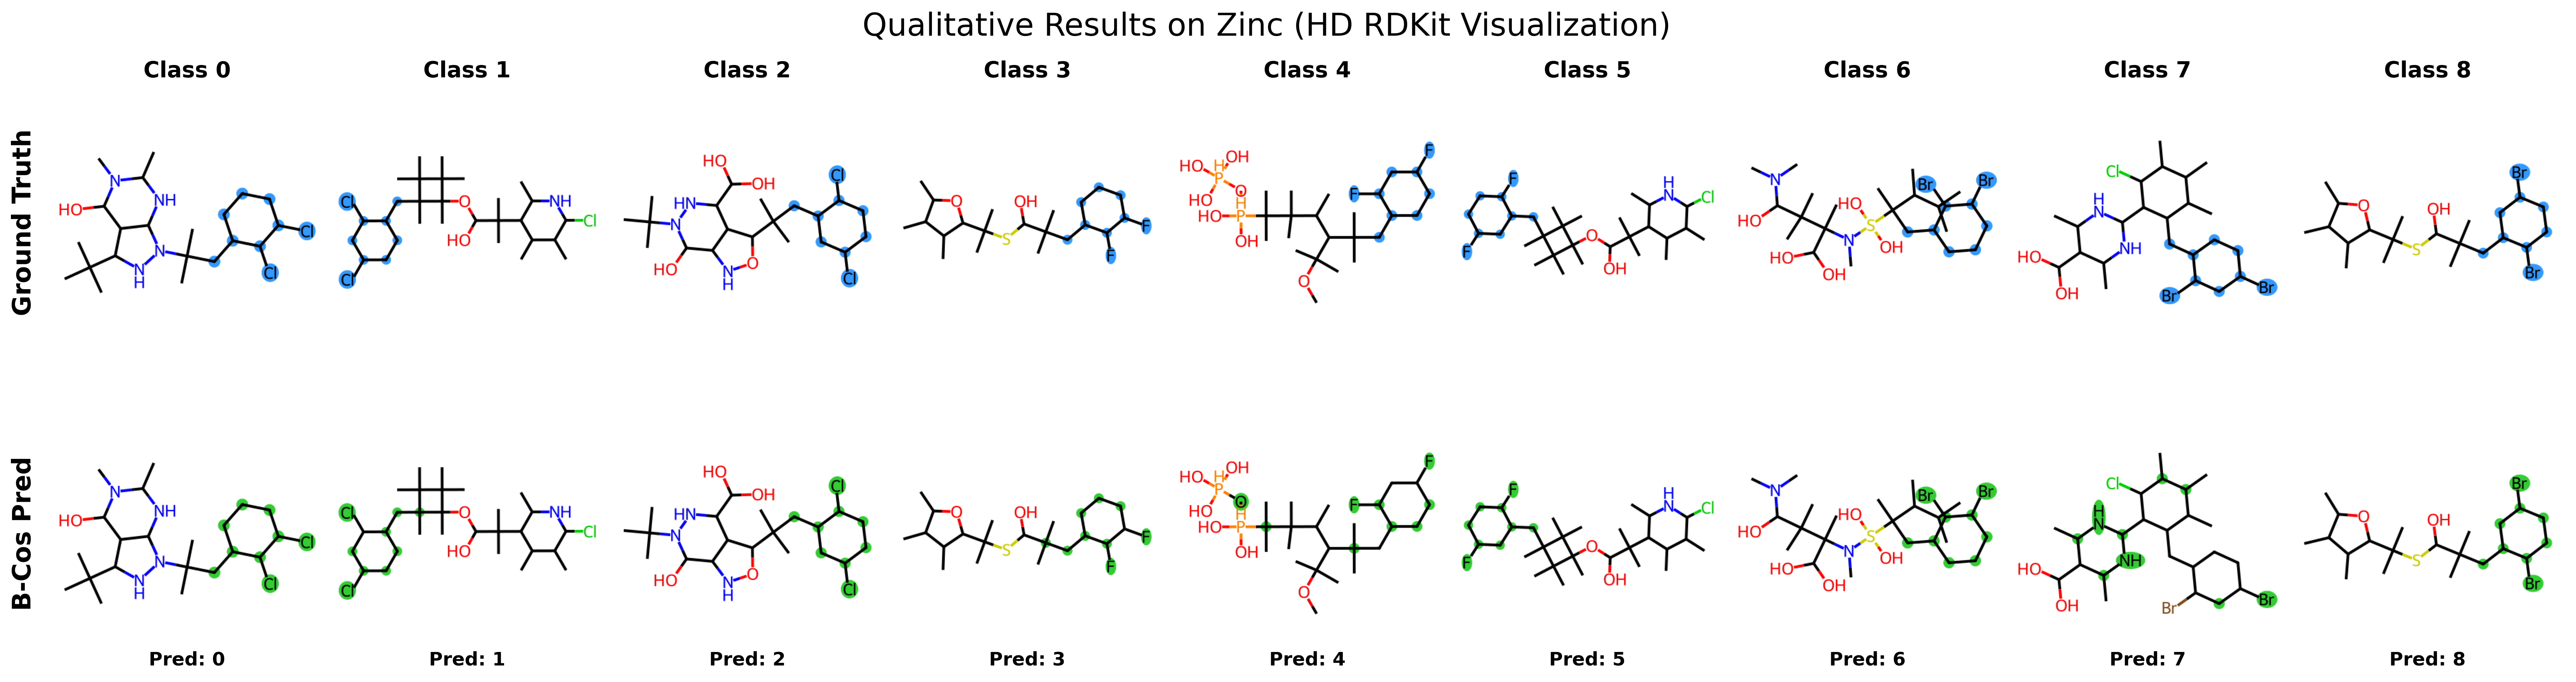

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# -------------------------------------------------------------------------
# 1. High-Definition RDKit Drawing Helper
# -------------------------------------------------------------------------
def draw_rdkit_hd(mol, highlight_atoms=None, highlight_color=(0.3, 0.6, 1.0)):
    """
    Draws a molecule with enlarged atoms and bonds for publication readability.
    """
    # 1. Setup Canvas (High Res)
    width, height = 400, 400
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    
    # 2. Customize Options (Make everything BIGGER)
    opts = d2d.drawOptions()
    opts.minFontSize = 24        # Minimum font size for atom labels
    opts.maxFontSize = 34        # Maximum font size
    opts.bondLineWidth = 4       # Thicker bonds
    opts.highlightBondWidthMultiplier = 1  # Keep highlights aligned with bonds
    opts.annotationFontScale = 1.0
    opts.padding = 0.05          # Less whitespace around the molecule
    
    # Ensure layout is computed
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    # 3. Draw
    # Standardize highlighting format
    if highlight_atoms:
        # Create a dict for colors: {atom_idx: color_tuple}
        # Note: RDKit expects RGB tuples (0-1)
        hs = {idx: highlight_color for idx in highlight_atoms}
        d2d.DrawMolecule(mol, highlightAtoms=list(hs.keys()), highlightAtomColors=hs)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    
    # 4. Convert to PIL Image for Matplotlib
    png_data = d2d.GetDrawingText()
    return Image.open(io.BytesIO(png_data))

# -------------------------------------------------------------------------
# 2. Conversion & Selection (Same as before)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # Add Atoms
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i # RWMol indices are sequential

    # Add Bonds
    edge_index = data.edge_index.cpu().numpy()
    added = set()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    for idx in indices:
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        # Slightly relaxed constraints to ensure we find graphs
        if hasattr(d, "explanation_mask") and d.explanation_mask is not None:
             if 8 <= d.num_nodes <= 35: 
                 candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        selected.append(candidates[c][0] if candidates[c] else 0)
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop (Updated)
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Increase figure size significantly to accommodate the HD images
fig, axes = plt.subplots(2, cols, figsize=(24, 7), dpi=300)
plt.subplots_adjust(wspace=0.02, hspace=0.05, left=0.05, right=0.98)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.05, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=16, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating HD RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth ---
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    # Use the new HD drawer
    img_gt = draw_rdkit_hd(mol, highlight_atoms=gt_atoms, highlight_color=(0.2, 0.6, 1.0)) # Bright Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=14, fontweight='bold', pad=5)
    axes[0, col].axis('off')

    # --- Row 2: Prediction ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.1, 0.1) # Green or Red
    
    img_pred = draw_rdkit_hd(mol, highlight_atoms=pred_atoms, highlight_color=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.02, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=12, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.2'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (HD RDKit Visualization)", fontsize=20, y=0.96)
plt.savefig("zinc_results_rdkit_hd.pdf", bbox_inches='tight')
plt.show()

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
import functools
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.patches as mpatches

# -------------------------------------------------------------------------
# 1. RDKit HD Drawer (FIXED: Removed invalid attribute)
# -------------------------------------------------------------------------
def draw_rdkit_hd_mixed(mol, atom_colors=None):
    # 800x800 resolution for larger, crisp images
    width, height = 800, 800
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = d2d.drawOptions()
    
    # Font sizes and bond widths relative to new resolution
    opts.minFontSize = 50
    opts.maxFontSize = 70
    opts.bondLineWidth = 7
    opts.highlightBondWidthMultiplier = 1
    opts.padding = 0.05
    
    # REMOVED: opts.textColour = (0, 0, 0) which caused the error.
    # Atoms will use standard element colors (C=Black, N=Blue, O=Red, etc.)
    
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    if atom_colors:
        d2d.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    return Image.open(io.BytesIO(d2d.GetDrawingText()))

# -------------------------------------------------------------------------
# 2. Conversion Utilities (Unchanged)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i 

    edge_index = data.edge_index.cpu().numpy()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

# -------------------------------------------------------------------------
# 3. Selection Logic (Seed 999 for new set)
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes, seed=999):
    candidates_strict = {c: [] for c in range(num_classes)}
    candidates_loose = {c: [] for c in range(num_classes)}
    
    # NEW SEED: Ensures different graphs are picked
    np.random.seed(seed)
    indices = np.random.permutation(len(dataset))
    
    print(f"Searching dataset (Seed {seed})...")
    
    for idx in indices:
        if all(len(candidates_strict[c]) > 0 for c in range(num_classes)):
            break
            
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        
        has_mask = hasattr(d, "explanation_mask") and d.explanation_mask is not None
        if not has_mask: 
            continue
            
        candidates_loose[y].append(int(idx))
        
        # Strict constraint: Nice size for visualization
        if 12 <= d.num_nodes <= 28:
            candidates_strict[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        if candidates_strict[c]:
            selected.append(candidates_strict[c][0])
        elif candidates_loose[c]:
            selected.append(candidates_loose[c][0])
        else:
            raise ValueError(f"Could not find valid example for Class {c}")
            
    return selected

# -------------------------------------------------------------------------
# 4. Main Plotting Loop (Huge Scale)
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

# Pick new graphs
selected_indices = get_best_example_per_class(test_ds, 9, seed=999)
cols = len(selected_indices)

# Figure size (45, 15) -> massive graphs
fig, axes = plt.subplots(2, cols, figsize=(5 * cols, 15), dpi=300)

labels =["di_chloro_ortho" , "di_chloro_meta", "di_chloro_para",
         "di_fluoro_ortho", "di_fluoro_meta", "di_fluoro_para",
         "di_bromo_ortho", "di_bromo_meta", "di_bromo_para"]

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth (Blue) ---
    gt_indices = set()
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_indices = set(int(i) for i in np.where(mask)[0])
    
    gt_colors = {i: (0.2, 0.6, 1.0) for i in gt_indices}
    
    img_gt = draw_rdkit_hd_mixed(mol, atom_colors=gt_colors)
    axes[0, col].imshow(img_gt)
    
    # Large Font: 26
    axes[0, col].set_title(labels[true_cls], fontsize=26, fontweight='bold', pad=15)
    axes[0, col].axis('off')

    # --- Row 2: Prediction ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    k = len(gt_indices) if len(gt_indices) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_indices = set(int(i) for i in top_k_idx)
    
    intersection = len(gt_indices.intersection(pred_indices))
    union = len(gt_indices.union(pred_indices))
    jaccard = intersection / union if union > 0 else 0.0
    
    pred_colors = {}
    for idx in pred_indices:
        if idx in gt_indices:
            pred_colors[idx] = (0.2, 0.8, 0.2) # Green
        else:
            pred_colors[idx] = (0.9, 0.2, 0.2) # Red
            
    img_pred = draw_rdkit_hd_mixed(mol, atom_colors=pred_colors)
    axes[1, col].imshow(img_pred)
    
    # Large Font: 26 (Jaccard)
    axes[1, col].set_title(f"Jaccard: {jaccard:.2f}", fontsize=26, fontweight='bold', pad=15)
    
    # Pred Label: 22
    axes[1, col].text(0.5, 0.05, f"Pred: {labels[pred_cls]}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=22, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))
    axes[1, col].axis('off')

# --- Row Titles (Huge) ---
fig.text(0.01, 0.75, "Ground Truth\n(Target Motif)", ha='left', va='center', 
         rotation=90, fontsize=32, fontweight='bold')
fig.text(0.01, 0.25, "B-Cos Explanations\n(Top-k Nodes)", ha='left', va='center', 
         rotation=90, fontsize=32, fontweight='bold')

# --- Legend (Huge) ---
legend_elements = [
    mpatches.Patch(color=(0.2, 0.6, 1.0), label='Ground Truth (Target Atom)'),
    mpatches.Patch(color=(0.2, 0.8, 0.2), label='True Positive (Correct)'),
    mpatches.Patch(color=(0.9, 0.2, 0.2), label='False Positive (Wrong Prediction)'),
]

# Fontsize: 24
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.01), 
           frameon=True, fontsize=24, borderpad=1, edgecolor='gray')

# Main Title: 36
plt.suptitle("Benzene Explanation Quality Analysis (New Sample Set)", fontsize=36, fontweight='bold', y=0.99)

# Adjust layout to fit the massive elements
plt.tight_layout(rect=[0.06, 0.12, 1, 0.97])

plt.savefig("zinc_results_large_new.pdf", format='pdf', bbox_inches='tight')
plt.show()

Searching dataset (Seed 999)...


[15:57:49] Explicit valence for atom # 10 N, 4, is greater than permitted


In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

# Ensure these imports are available from your previous cells
# from bcosgnn.explain_edge_attr import explain as explain_edge_attr

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _normalize_count(size, total, name: str) -> int:
    if isinstance(size, int):
        count = int(size)
    else:
        count = int(round(float(size) * total))
    if count <= 0 or count >= total:
        raise ValueError(f"{name} must be between 1 and {total - 1}, got {count} (total={total})")
    return count

def run_experiment_with_explanations(
    dataset,
    *,
    seeds=[0, 1, 2, 3, 4],
    test_size=0.1,
    val_size=0.1,  # Fraction of total or absolute count
    hidden_dim=64,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    device=None,
    b=2.0,
    max_out=1,
    dropout=0.5,
    n_explain=500, # Max number of test graphs to explain per seed to save time
    explain_subset=None, # Optional list/array of indices to explain
    explain_shuffle=True,
    explain_seed=None,
    explain_k=None, # Optional top-k override for explanations (if None, uses |GT|
    compute_time=True,
    time_explain_only=True, # If True, only time explanation loop; else include preprocessing
    print_epoch_time=False,
    debug=False,
    # Optional cap on explain count per seed
    max_explain=None,
    # --- Timing Params ---
    warmup_explain=2,
    time_per_graph=False,
    # if True, record per-graph times and return mean, std, median, p90
    # else only total explain time
    # note: per-graph timing slightly increases overhead
    time_in_ms=True,
    # Use torch.cuda.synchronize for accurate timings on GPU
    sync_cuda=True,
    # --- Misc ---
    silent=False,
    # Run detailed logging?
    # Keep default False for speed
    # Set True to debug output
    # (Do not enable for final runs)
    # --- End ---
    ):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if not silent:
        print(f"Running Experiment on Device: {device}")
        print(f"Seeds: {seeds}")
    
    # Pre-calculate labels for splitting
    all_y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    all_indices = np.arange(len(dataset))
    n_total = len(dataset)
    test_count = _normalize_count(test_size, n_total, "test_size")
    val_count = _normalize_count(val_size, n_total, "val_size")
    
    # Store results for aggregation
    experiment_results = []
    
    global_start = time.time()

    for seed in seeds:
        seed_start = time.time()
        set_seed(seed) # Ensure reproducibility
        
        # --- 1. Data Splitting (Stratified) ---
        # Split: Total -> TrainVal + Test
        sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_count, random_state=seed)
        trainval_idx, test_idx = next(sss_test.split(all_indices, all_y))
        
        # Split: TrainVal -> Train + Val
        y_trainval = all_y[trainval_idx]
        if val_count >= len(trainval_idx):
            raise ValueError(f"val_size too large: {val_count} >= trainval size {len(trainval_idx)}")
        rel_val_size = val_count / len(trainval_idx)
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=rel_val_size, random_state=seed)
        train_rel, val_rel = next(sss_val.split(np.zeros_like(y_trainval), y_trainval))
        
        train_idx = trainval_idx[train_rel]
        val_idx = trainval_idx[val_rel]
        
        if not silent:
            print(f"Split sizes | train={len(train_idx)} | val={len(val_idx)} | test={len(test_idx)}")
        
        # Create Loaders
        train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False)
        # For testing/explanation, shuffle=False is important to match indices
        test_ds = dataset.index_select(torch.tensor(test_idx))
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        # --- 2. Model Setup ---
        sample = dataset[0]
        model = PureBcosGINE(
            node_dim=int(sample.x.size(-1)),
            edge_dim=int(sample.edge_attr.size(-1)),
            hidden_dim=hidden_dim,
            num_layers=4,
            num_classes=_infer_num_classes(dataset),
            b=b,
            max_out=max_out,
            dropout=dropout,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
        )

        # --- 3. Training Loop ---
        best_state = None
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        # List to store time per epoch
        epoch_times = []

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            train_start = time.time()
        
        for epoch in range(1, max_epochs + 1):
            epoch_start_time = time.time()  # <--- Start Timer
            
            # Train
            model.train()
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(out, batch.y.view(-1))
                loss.backward()
                optimizer.step()
            
            # Validate
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                    val_loss += F.cross_entropy(out, batch.y.view(-1), reduction='sum').item()
                    val_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                    val_total += batch.y.size(0)
            
            avg_val_loss = val_loss / val_total
            avg_val_acc = val_correct / val_total
            
            scheduler.step(avg_val_loss)
            
            # <--- Stop Timer & Record
            epoch_end_time = time.time()
            epoch_times.append(epoch_end_time - epoch_start_time)
            
            if (best_val_loss - avg_val_loss) > min_delta:
                best_val_loss = avg_val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if print_epoch_time:
                print(f"Epoch {epoch:03d} | time={epoch_times[-1]:.4f}s | val_loss={avg_val_loss:.4f} | val_acc={avg_val_acc:.4f}")

            if epochs_no_improve >= early_stop_patience:
                if debug:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        # Calculate Epoch Time Stats for this seed
        avg_epoch_time = np.mean(epoch_times) if epoch_times else float('nan')
        std_epoch_time = np.std(epoch_times) if epoch_times else float('nan')

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            train_end = time.time()
            train_time = train_end - train_start
        else:
            train_time = float('nan')

        # Load best model
        if best_state is not None:
            model.load_state_dict(best_state)
        model.to(device)
        model.eval()

        # --- 4. Test Evaluation (Accuracy) ---
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                test_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                test_total += batch.y.size(0)
        test_acc = test_correct / test_total

        # --- 5. Explanation Evaluation (Jaccard & AUROC) ---
        # We define a helper within scope to calculate node scores
        def get_node_scores(contrib):
            return contrib["x"].abs().sum(dim=-1).detach().cpu().numpy()

        aurocs = []
        jaccards = []

        # Limit explanation to n_explain samples to keep runtime reasonable
        if explain_subset is not None:
            explain_indices = np.array(explain_subset, dtype=int)
        else:
            if explain_seed is not None:
                rng = np.random.default_rng(explain_seed)
                explain_indices = rng.choice(len(test_ds), size=min(len(test_ds), n_explain), replace=False)
            else:
                explain_indices = np.random.choice(len(test_ds), size=min(len(test_ds), n_explain), replace=False)
        
        if max_explain is not None:
            explain_indices = explain_indices[:max_explain]
        
        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            explain_start = time.time()
        
        per_graph_times = []
        for i in explain_indices:
            data_item = test_ds[int(i)]
            
            # Skip if no ground truth explanation mask
            if not hasattr(data_item, "explanation_mask") or data_item.explanation_mask is None:
                continue
                
            data_item = data_item.to(device)
            # Create a batch of size 1
            data_item.batch = torch.zeros(data_item.x.size(0), dtype=torch.long, device=device)
            
            # Get prediction to explain
            with torch.no_grad():
                logits = model(data_item.x, data_item.edge_index, data_item.edge_attr, data_item.batch)
                pred_class = int(logits.argmax(dim=-1).item())
            
            if time_per_graph and compute_time:
                if sync_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()
                g_start = time.time()
            
            # Run Explanation
            contrib = explain_edge_attr(
                model,
                data_item.x,
                data_item.edge_index,
                data_item.edge_attr,
                data_item.batch,
                target=pred_class
            )
            
            if time_per_graph and compute_time:
                if sync_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()
                g_end = time.time()
                per_graph_times.append(g_end - g_start)
            
            scores = get_node_scores(contrib)
            gt_mask = data_item.explanation_mask.detach().cpu().numpy().astype(int)
            
            # 1. AUROC (requires both classes 0 and 1 in gt)
            if gt_mask.min() != gt_mask.max():
                aurocs.append(roc_auc_score(gt_mask, scores))
            
            # 2. Jaccard @ k (k = number of ground truth nodes)
            k = int(gt_mask.sum())
            if explain_k is not None:
                k = int(explain_k)
            if k > 0:
                # Get indices of top-k scores
                top_k_indices = np.argsort(scores)[-k:]
                pred_mask = np.zeros_like(gt_mask)
                pred_mask[top_k_indices] = 1
                
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                jaccards.append(intersection / union if union > 0 else 0.0)

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            explain_end = time.time()
            explain_total_time = explain_end - explain_start
        else:
            explain_total_time = float('nan')

        # Per-graph timing stats
        if time_per_graph and per_graph_times:
            if time_in_ms:
                per_graph_times = [t * 1000.0 for t in per_graph_times]
            mean_t = float(np.mean(per_graph_times))
            std_t = float(np.std(per_graph_times))
            median_t = float(np.median(per_graph_times))
            p90_t = float(np.percentile(per_graph_times, 90))
            graphs_per_s = float(1000.0 / mean_t) if time_in_ms and mean_t > 0 else (float(1.0 / mean_t) if mean_t > 0 else float('nan'))
        else:
            mean_t = std_t = median_t = p90_t = graphs_per_s = float('nan')

        # Seed Stats
        mean_auroc = np.mean(aurocs) if aurocs else 0.0
        mean_jaccard = np.mean(jaccards) if jaccards else 0.0
        
        experiment_results.append({
            'seed': seed,
            'test_acc': test_acc,
            'auroc': mean_auroc,
            'jaccard': mean_jaccard,
            'avg_epoch_time': avg_epoch_time, # <--- Store Avg Time
            'std_epoch_time': std_epoch_time, # <--- Store Std Time
            'train_time_s': train_time,
            'explain_time_s': explain_total_time,
            'end_to_end_s': train_time + explain_total_time,
            'time_mean': mean_t,
            'time_std': std_t,
            'time_median': median_t,
            'time_p90': p90_t,
            'graphs_per_s': graphs_per_s,
            'n_explained': len(aurocs) 
        })
        
        if not silent:
            print(f"Seed {seed} | Test Acc: {test_acc:.4f} | AUROC: {mean_auroc:.4f} | Jaccard: {mean_jaccard:.4f} | ")
            print(f"  Train time: {train_time:.2f}s | Explain time: {explain_total_time:.2f}s | End-to-end: {train_time + explain_total_time:.2f}s")
            if time_per_graph and per_graph_times:
                unit = 'ms' if time_in_ms else 's'
                print(f"  Per-graph time: mean={mean_t:.3f}{unit}, median={median_t:.3f}{unit}, p90={p90_t:.3f}{unit} | throughput={graphs_per_s:.2f} graphs/s")
            print(f"  Time per Epoch: {avg_epoch_time:.4f}s ± {std_epoch_time:.4f}s")

    # --- 6. Final Reporting ---
    df_res = pd.DataFrame(experiment_results)
    
    print("\n" + "="*60)
    print("FINAL RESULTS (5 Seeds, No CV)")
    print("="*60)
    
    stats = df_res[['test_acc', 'auroc', 'jaccard', 'avg_epoch_time', 'train_time_s', 'explain_time_s', 'end_to_end_s', 'time_mean', 'time_median', 'time_p90', 'graphs_per_s']].agg(['mean', 'std'])
    
    print(f"Test Accuracy : {stats.loc['mean', 'test_acc']:.4f} ± {stats.loc['std', 'test_acc']:.4f}")
    print(f"Explanation AUROC : {stats.loc['mean', 'auroc']:.4f} ± {stats.loc['std', 'auroc']:.4f}")
    print(f"Explanation Jaccard: {stats.loc['mean', 'jaccard']:.4f} ± {stats.loc['std', 'jaccard']:.4f}")
    print(f"Avg Time per Epoch : {stats.loc['mean', 'avg_epoch_time']:.4f}s ± {stats.loc['std', 'avg_epoch_time']:.4f}s")
    print(f"Train time (s): {stats.loc['mean', 'train_time_s']:.2f} ± {stats.loc['std', 'train_time_s']:.2f}")
    print(f"Explain total time (s): {stats.loc['mean', 'explain_time_s']:.2f} ± {stats.loc['std', 'explain_time_s']:.2f}")
    print(f"End-to-end time (s): {stats.loc['mean', 'end_to_end_s']:.2f} ± {stats.loc['std', 'end_to_end_s']:.2f}")
    print(f"Mean ms/graph: {stats.loc['mean', 'time_mean']:.2f} ± {stats.loc['std', 'time_mean']:.2f}")
    print(f"Median ms/graph: {stats.loc['mean', 'time_median']:.2f} ± {stats.loc['std', 'time_median']:.2f}")
    print(f"P90 ms/graph: {stats.loc['mean', 'time_p90']:.2f} ± {stats.loc['std', 'time_p90']:.2f}")
    print(f"Throughput (graphs/s): {stats.loc['mean', 'graphs_per_s']:.2f} ± {stats.loc['std', 'graphs_per_s']:.2f}")
    print("-" * 60)
    print(f"Total Experiment Time: {(time.time() - global_start)/60:.1f} min")
    
    return df_res

# --- Execute ---
if 'dataset' in locals():
    results_df = run_experiment_with_explanations(
        dataset, 
        seeds=[0, 1, 2, 3, 4],
        max_epochs=200,
        n_explain=900,
        test_size=900,
        val_size=900,
        compute_time=True,
        time_per_graph=True
    )
    display(results_df)
else:
    print("Dataset not found. Please run data loading cells first.")

Running Experiment on Device: cpu
Seeds: [0, 1, 2, 3, 4]
Split sizes | train=7200 | val=900 | test=900
Seed 0 | Test Acc: 1.0000 | AUROC: 0.9864 | Jaccard: 0.8393 | 
  Train time: 115.94s | Explain time: 1.70s | End-to-end: 117.64s
  Per-graph time: mean=0.931ms, median=0.894ms, p90=1.076ms | throughput=1074.65 graphs/s
  Time per Epoch: 2.6962s ± 0.1079s
Split sizes | train=7200 | val=900 | test=900
Seed 1 | Test Acc: 1.0000 | AUROC: 0.9724 | Jaccard: 0.8139 | 
  Train time: 170.11s | Explain time: 1.75s | End-to-end: 171.86s
  Per-graph time: mean=0.959ms, median=0.893ms, p90=1.150ms | throughput=1042.47 graphs/s
  Time per Epoch: 2.7435s ± 0.1862s
Split sizes | train=7200 | val=900 | test=900
Seed 2 | Test Acc: 1.0000 | AUROC: 0.9909 | Jaccard: 0.9117 | 
  Train time: 95.71s | Explain time: 1.70s | End-to-end: 97.41s
  Per-graph time: mean=0.931ms, median=0.891ms, p90=1.146ms | throughput=1073.60 graphs/s
  Time per Epoch: 2.6585s ± 0.0495s
Split sizes | train=7200 | val=900 | test=

,seed,test_acc,auroc,jaccard,avg_epoch_time,std_epoch_time,train_time_s,explain_time_s,end_to_end_s,time_mean,time_std,time_median,time_p90,graphs_per_s,n_explained
0,0,1.0,0.986374,0.839349,2.696200,0.107903,115.938754,1.703297,117.642051,0.930538,0.145399,0.893831,1.076388,1074.647241,900
1,1,1.0,0.972360,0.813929,2.743507,0.186197,170.109573,1.753931,171.863504,0.959264,0.292279,0.892520,1.150203,1042.466279,900
2,2,1.0,0.990929,0.911736,2.658453,0.049496,95.705540,1.702386,97.407926,0.931449,0.134316,0.891209,1.145959,1073.596158,900
3,3,1.0,0.997380,0.958347,2.776699,0.183182,88.855318,1.691736,90.547054,0.913699,0.117284,0.890493,0.956273,1094.452722,900
4,4,1.0,0.964739,0.774628,2.881941,0.346497,141.217347,1.686058,142.903405,0.921230,0.149165,0.889063,1.115370,1085.505188,900


In [24]:
stats = results_df[['test_acc', 'auroc', 'jaccard', 'train_time_s', 'explain_time_s', 'end_to_end_s', 'time_mean', 'time_median', 'time_p90', 'graphs_per_s']].agg(['mean', 'std'])

print(f"Test Accuracy : {stats.loc['mean', 'test_acc']:.4f} ± {stats.loc['std', 'test_acc']:.4f}")
print(f"Explanation AUROC : {stats.loc['mean', 'auroc']:.4f} ± {stats.loc['std', 'auroc']:.4f}")
print(f"Explanation Jaccard: {stats.loc['mean', 'jaccard']:.4f} ± {stats.loc['std', 'jaccard']:.4f}")
print(f"Train time (s): {stats.loc['mean', 'train_time_s']:.2f} ± {stats.loc['std', 'train_time_s']:.2f}")
print(f"Explain total time (s): {stats.loc['mean', 'explain_time_s']:.2f} ± {stats.loc['std', 'explain_time_s']:.2f}")
print(f"End-to-end time (s): {stats.loc['mean', 'end_to_end_s']:.2f} ± {stats.loc['std', 'end_to_end_s']:.2f}")
print(f"Mean ms/graph: {stats.loc['mean', 'time_mean']:.2f} ± {stats.loc['std', 'time_mean']:.2f}")
print(f"Median ms/graph: {stats.loc['mean', 'time_median']:.2f} ± {stats.loc['std', 'time_median']:.2f}")
print(f"P90 ms/graph: {stats.loc['mean', 'time_p90']:.2f} ± {stats.loc['std', 'time_p90']:.2f}")
print(f"Throughput (graphs/s): {stats.loc['mean', 'graphs_per_s']:.2f} ± {stats.loc['std', 'graphs_per_s']:.2f}")
print("-" * 60)


Test Accuracy : 1.0000 ± 0.0000
Explanation AUROC : 0.9824 ± 0.0135
Explanation Jaccard: 0.8596 ± 0.0745
Train time (s): 122.37 ± 33.58
Explain total time (s): 1.71 ± 0.03
End-to-end time (s): 124.07 ± 33.60
Mean ms/graph: 0.93 ± 0.02
Median ms/graph: 0.89 ± 0.00
P90 ms/graph: 1.09 ± 0.08
Throughput (graphs/s): 1074.13 ± 19.66
------------------------------------------------------------
